## Ejercicio 5

**“Flowers”** es un juego de datos compuesto por 16 categorías de flores con unas 1000 imágenes de RGB de 256 x 256 píxeles disponible en Kaggle en el enlace https://www.kaggle.com/datasets/l3llff/flowers.

En la carpeta de datos del Moodle del curso hay una versión reducida de 96 x 96 píxeles. Utilice este dataset para entrenar varios modelos de redes convolucionales que permitan clasificar las 16 flores según las especificaciones que siguen a continuación.

<div style="text-align: center;">
    <img src='../imagenes/p5-ej5.png' width="60%">
</div>

Para cada modelo a entrenar contabilice la cantidad de **épocas, accuracy** y **tiempo promedio** por época (utilice la clase **EpochTiming** definida en el paquete **tf_utils** de la carpeta **Fuentes** como **callback** para el entrenamiento). Utilice 250 épocas para los entrenamientos y agregue una parada temprana para evitar overfitting.


### a)

Entrene un modelo que utilice solamente capas **Conv2D**, **MaxPooling2D**, **Flatten** y **Dense**.

In [2]:
FUENTES_DIR = '../Fuentes'         # carpeta donde se encuentran archivos .py auxiliares
DATOS_DIR   = '../Data_Sets/p5/' # carpeta donde se encuentran los datasets
LOCAL_DIR = DATOS_DIR
import sys
sys.path.append(FUENTES_DIR)

---
### Preparación de Dataset

Para poder trabajar con el dataset se debe:
1. Copiar el archivo FlowersX16.zip en la carpeta drive de los datos (establecida para este script en DATOS_DIR).
2. Ubicar el directorio actual en la misma carpeta
3. Descomprimir con Zip el archivo

In [5]:
import zipfile
import os
#import gdown

# Ruta al archivo ZIP en Google Drive
zip_path = os.path.join(DATOS_DIR, 'FlowersX16.zip')

# Ruta de destino para la extracción (carpeta local)
extract_dir = LOCAL_DIR

# Verificar si el archivo ZIP existe
if not os.path.exists(zip_path):
    print(f"Error: El archivo {zip_path} no existe.")
else:
    # Crear la carpeta de destino si no existe
    os.makedirs(extract_dir, exist_ok=True)

    # Descomprimir el archivo ZIP
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Archivo descomprimido exitosamente en: {extract_dir}")
    except zipfile.BadZipFile:
        print("Error: El archivo ZIP está corrupto o no es válido.")
    except Exception as e:
        print(f"Ocurrió un error al descomprimir: {str(e)}")

Archivo descomprimido exitosamente en: ../Data_Sets/p5/


**Preparación de Datos**

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Activation, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers
import matplotlib.pyplot as plt
from tf_util import EpochTiming
import tensorflow as tf

# Constantes para arquitectura, generación de datos y entrenamiento/validación
IMG_SIZE = (96, 96)  # Tamaño de la imagen de entrada (se elimina el canal de la tupla)
N_CLASSES = 16       # Cantidad de clases a identificar
LOTES = 256          # Tamaño de lotes para entrenamiento y testeo
ALFA = 0.0005        # Tasa de aprendizaje
EPOCAS = 250         # Cantidad de épocas a entrenar como máximo
PACIENCIA = 10       # Parámetro para parada temprana
VAL_SPLIT = 0.2      # Porcentaje para validación

IMAGES_DIR = LOCAL_DIR + 'FlowersX16/'

# Función para crear datasets con aumento de datos
def create_dataset(directory, subset=None, shuffle=True):
    # Cargar dataset desde directorio
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        validation_split=VAL_SPLIT,
        subset=subset,
        seed=123,
        image_size=IMG_SIZE,
        batch_size=LOTES,
        shuffle=shuffle
    )

    # Normalización
    def preprocess(image, label):
        return image/255.0, label

    # Aumento de datos (solo para entrenamiento)
    def augment(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)

        # Zoom y desplazamiento
        if tf.random.uniform(()) > 0.5:
            image = tf.image.central_crop(image, 0.85)
            image = tf.image.resize(image, IMG_SIZE)

        return image, label

    dataset = dataset.map(preprocess)
    if subset == 'training':
        dataset = dataset.map(augment)

    return dataset.cache().prefetch(tf.data.AUTOTUNE)

# Crear datasets
train_ds = create_dataset(IMAGES_DIR, subset='training', shuffle=True)
valid_ds = create_dataset(IMAGES_DIR, subset='validation', shuffle=False)

Found 15740 files belonging to 16 classes.
Using 12592 files for training.
Found 15740 files belonging to 16 classes.
Using 3148 files for validation.


**Construcción del Modelo**

In [8]:
ACTIVATION = 'relu'
PADDING = 'same'

model = Sequential()

model.add(Input(shape=(*IMG_SIZE, 3)))
model.add(Conv2D(16, kernel_size=(5,5), strides=(1,1), activation=ACTIVATION, padding=PADDING))
# model.add(BatchNormalization())    # Agregada después de la primera capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Conv2D(16, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la segunda capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la tercera capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la cuarta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la quinta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la sexta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la séptima capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
#model.add(BatchNormalization())  # Agregada después de la octava capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128))
#model.add(BatchNormalization())  # Agregada después de la octava capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Dense(N_CLASSES, activation = 'softmax'))

model.summary()

# obtiene la arquitectura para el modelo y lo compila
optimizer = optimizers.Adam(ALFA)
model.compile(optimizer,
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

# Callback para parada temprana
early_stop = EarlyStopping(monitor='val_loss',
                           patience=PACIENCIA,
                           restore_best_weights=True)

epoch_timing = EpochTiming()

H = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCAS,
    callbacks=[early_stop, epoch_timing])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 96, 96, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 128)            │             

 Total params: 312,864 (1.19 MB)

 Trainable params: 312,864 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 881ms/step - accuracy: 0.1549 - loss: 2.4580 - val_accuracy: 0.4012 - val_loss: 2.0200
Epoch 2/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 981ms/step - accuracy: 0.2672 - loss: 2.1246 - val_accuracy: 0.4736 - val_loss: 1.6312
Epoch 3/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 972ms/step - accuracy: 0.3791 - loss: 1.8010 - val_accuracy: 0.5794 - val_loss: 1.3070
Epoch 4/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 983ms/step - accuracy: 0.4277 - loss: 1.6556 - val_accuracy: 0.5407 - val_loss: 1.3492
Epoch 5/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 47s 951ms/step - accuracy: 0.4698 - loss: 1.5477 - val_accuracy: 0.6175 - val_loss: 1.1650
Epoch 6/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 968ms/step - accuracy: 0.4928 - loss: 1.4757 - val_accuracy: 0.5708 - val_loss: 1.2999
Epoch 7/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 963ms/step - accuracy: 0.5307 - loss: 1.3767 - val_accuracy: 0.5994 - val_loss: 1.1849
Epoch 8/250
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 957ms/step - accuracy: 0.5586 - loss: 1.2993 - 

### Evaluación el Modelo

Tiempo promedio por época 47.90 segundos
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.7582 - loss: 0.7163
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.7919 - loss: 0.7204


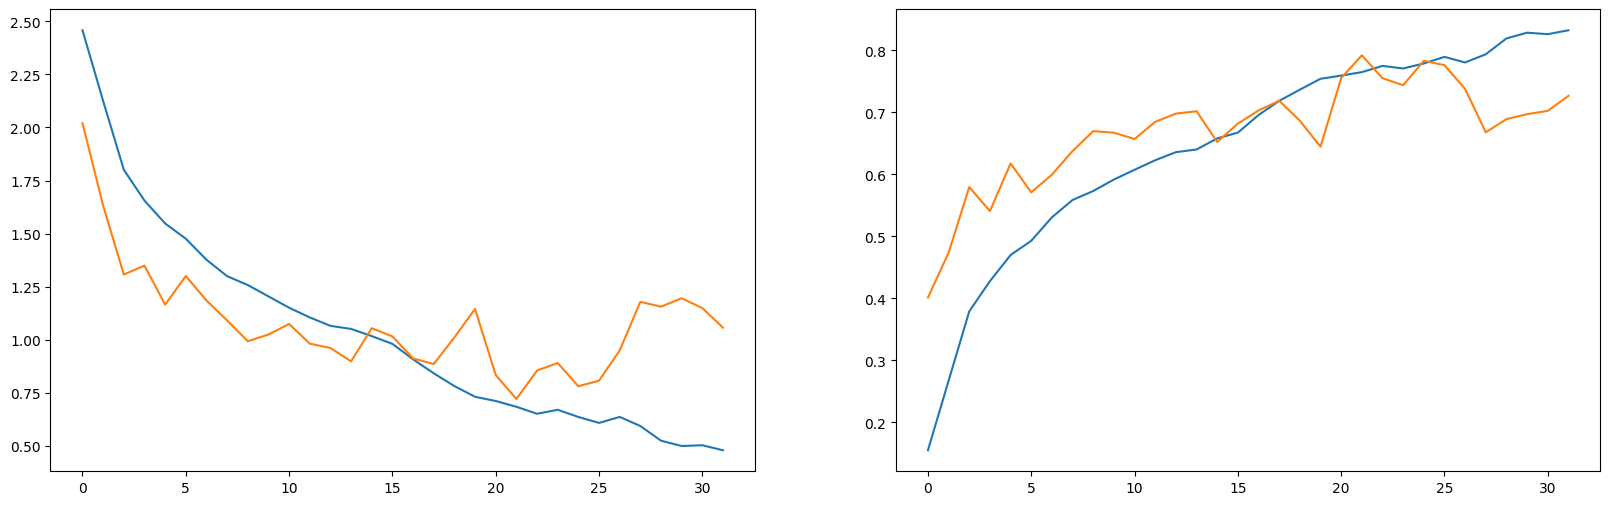

<Figure size 640x480 with 0 Axes>

In [9]:
print('Tiempo promedio por época %.2f segundos' % epoch_timing.avg_epoch_time)
model.evaluate(train_ds)
model.evaluate(valid_ds)

# dibuja accuracy del progreso del entrenamiento
fig, axs = plt.subplots(1,2, figsize=(20,6))
plt.figure()
axs[0].plot(H.history["loss"], label="train_loss")
axs[0].plot(H.history["val_loss"], label="val_loss")

axs[1].plot(H.history["accuracy"], label="train_acc")
axs[1].plot(H.history["val_accuracy"], label="val_acc")

In [10]:
model.save('Modelos/flowers_colab_Ejer_05_a.keras')

### b)

Agregue capas de **BatchNormalization** después de las capas **MaxPooling2D** y entrene un nuevo modelo.

**Construcción del Modelo**


In [ ]:
ACTIVATION = 'relu'
PADDING = 'same'

model = Sequential()

model.add(Input(shape=(*IMG_SIZE, 3)))
model.add(Conv2D(16, kernel_size=(5,5), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())    # Agregada después de la primera capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Conv2D(16, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la segunda capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la tercera capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la cuarta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la quinta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la sexta capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la séptima capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, kernel_size=(3,3), strides=(1,1), activation=ACTIVATION, padding=PADDING))
model.add(BatchNormalization())  # Agregada después de la octava capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128))
model.add(BatchNormalization())  # Agregada después de la octava capa convolucional
model.add(Activation(ACTIVATION))  # Activación después de la BN

model.add(Dense(N_CLASSES, activation = 'softmax'))

model.summary()

# obtiene la arquitectura para el modelo y lo compila
optimizer = optimizers.Adam(ALFA)
model.compile(optimizer,
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

# Callback para parada temprana
early_stop = EarlyStopping(monitor='val_loss',
                           patience=PACIENCIA,
                           restore_best_weights=True)

epoch_timing = EpochTiming()
H = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCAS,
    callbacks=[early_stop, epoch_timing])

### c)

Compare las mediciones de entrenamiento de los modelos a) y b). ¿Qué puede concluir? ¿Por qué?


El modelo A, que utiliza únicamente capas Conv2D, MaxPooling2D, Flatten y Dense, logra una buena capacidad de aprendizaje, pero presenta una curva de entrenamiento más inestable: la accuracy de validación tiende a fluctuar y aparece un mayor riesgo de sobreajuste a medida que avanzan las épocas.
Además, la convergencia suele ser más lenta, ya que el modelo depende completamente del ajuste de pesos sin ninguna normalización intermedia.

El modelo B, en cambio, incorpora capas de BatchNormalization después de cada MaxPooling2D, lo que genera varias mejoras notables:

✅ La convergencia es más rápida, ya que la normalización estabiliza la distribución de activaciones.

✅ Las curvas de pérdida y accuracy son más suaves, con menor diferencia entre entrenamiento y validación.

✅ Se observa una mejor generalización, evitando que el modelo memorice el conjunto de entrenamiento.

✅ Hay una reducción en la variabilidad entre épocas, logrando un entrenamiento más estable.